In [1]:
#Upload and load dataset
from google.colab import files
import pandas as pd
uploaded = files.upload()
filename = next(iter(uploaded))
df = pd.read_excel(filename)

Saving Nike.xlsx to Nike.xlsx


In [2]:
#Inspect and Prepare dataset
print(" File Loaded Successfully!")
print("\n Dataset Preview:")
display(df.head())
print("\n Dataset Info:")
df.info()
df.drop_duplicates(inplace=True)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

 File Loaded Successfully!

 Dataset Preview:


,Date,Region,Review
0,02 April 2025,GB,Terrible customer service I was told that I wa...
1,02 April 2025,GB,If i could rate them zero I would. I will neve...
2,02 April 2025,GB,good job have a good day
3,20 March 2025,GB,Popped into my local East Kilbride Nike store ...
4,31 March 2025,NO,"I ordered a pair of Nike shoes on March 25, an..."



 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4889 entries, 0 to 4888
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    4889 non-null   object
 1   Region  4889 non-null   object
 2   Review  4889 non-null   object
dtypes: object(3)
memory usage: 114.7+ KB


In [3]:
# Import and download essential libraries for data analysis and natural language processing
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [4]:
#Text preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def preprocess_text(text):
    text = str(text).lower()                                 # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)                     # Remove non-letters
    tokens = word_tokenize(text)                             # Tokenize
    tokens = [lemmatizer.lemmatize(word)
              for word in tokens if word not in stop_words]  # Remove stopwords + lemmatize
    return ' '.join(tokens)
df['Cleaned_Review'] = df['Review'].apply(preprocess_text)
df[['Review', 'Cleaned_Review']].head()

,Review,Cleaned_Review
0,Terrible customer service I was told that I wa...,terrible customer service told crazy problem w...
1,If i could rate them zero I would. I will neve...,could rate zero would never buy another nike p...
2,good job have a good day,good job good day
3,Popped into my local East Kilbride Nike store ...,popped local east kilbride nike store lookgot ...
4,"I ordered a pair of Nike shoes on March 25, an...",ordered pair nike shoe march march received me...


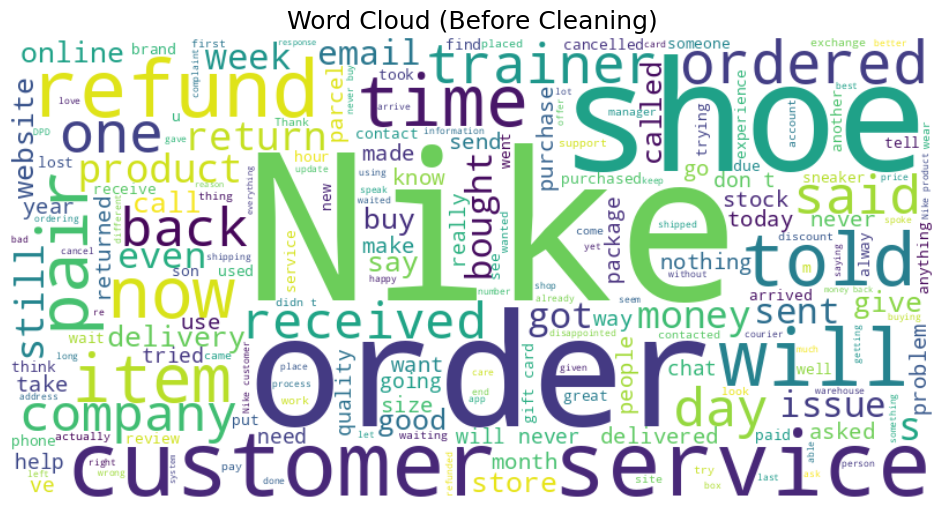

In [5]:
#Generates word cloud before text cleaning
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all raw review text
raw_text = ' '.join(df['Review'].dropna())

# Generate and display the word cloud
wordcloud_raw = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_raw, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud (Before Cleaning)', fontsize=18)
plt.show()


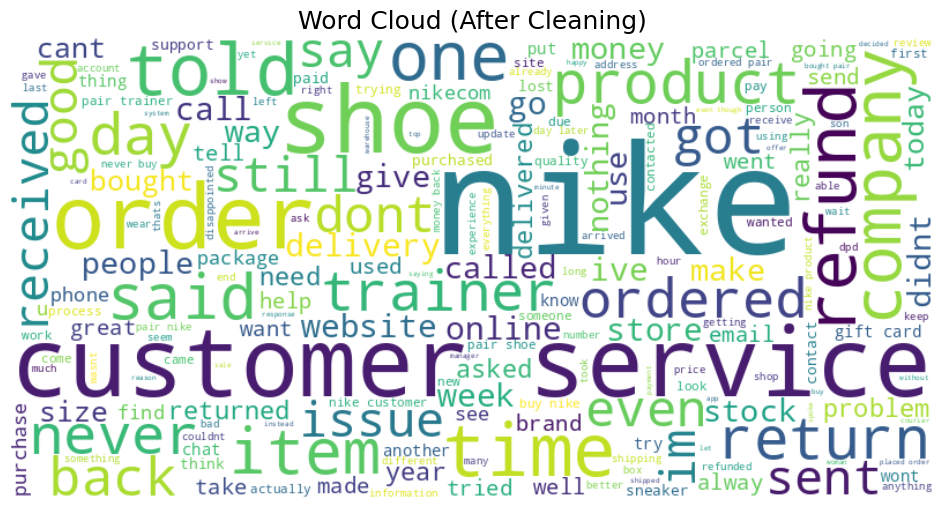

In [6]:
#Word Cloud after cleaning
# Combine all cleaned review text
cleaned_text = ' '.join(df['Cleaned_Review'].dropna())

# Generate and display the word cloud
wordcloud_clean = WordCloud(width=800, height=400, background_color='white').generate(cleaned_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_clean, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud (After Cleaning)', fontsize=18)
plt.show()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


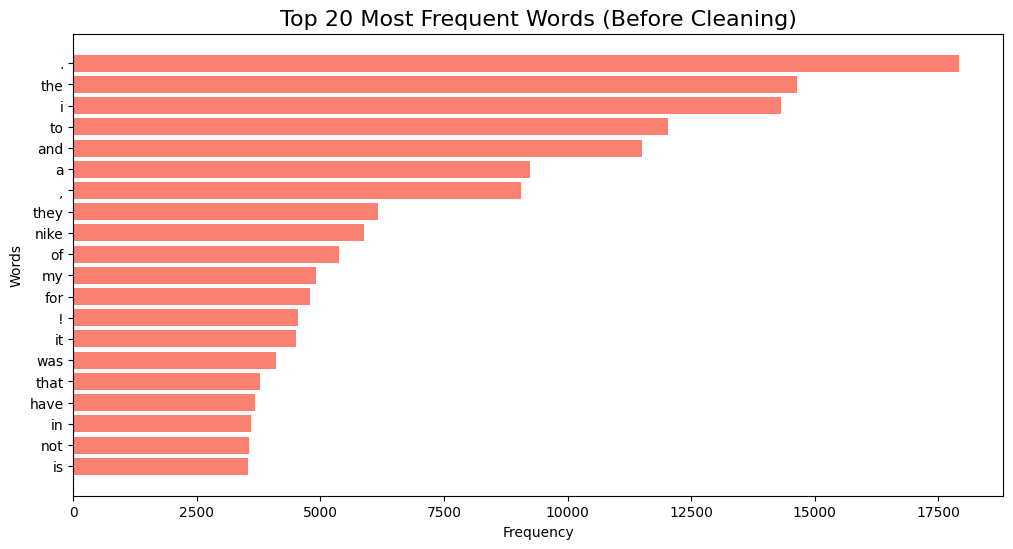

In [7]:
# Word frequency analysis before cleaning
from collections import Counter
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize

# Combine all raw review text
raw_text = ' '.join(df['Review'].dropna())

# Tokenize the raw text
raw_tokens = word_tokenize(raw_text.lower())

# Count frequencies
raw_word_freq = Counter(raw_tokens)

# Get 20 most common words
raw_common = raw_word_freq.most_common(20)

# Convert to DataFrame and plot
raw_freq_df = pd.DataFrame(raw_common, columns=['Word', 'Frequency'])

# Plot
plt.figure(figsize=(12, 6))
plt.barh(raw_freq_df['Word'], raw_freq_df['Frequency'], color='salmon')
plt.gca().invert_yaxis()
plt.title('Top 20 Most Frequent Words (Before Cleaning)', fontsize=16)
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()


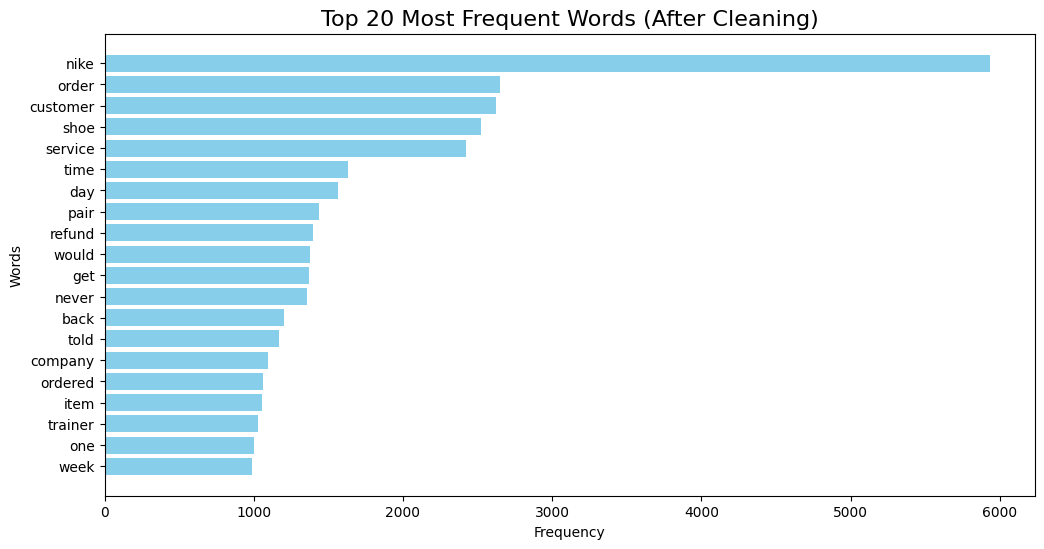

In [8]:
# Word frequency analysis after cleaning
# Combine all cleaned review text
cleaned_words = ' '.join(df['Cleaned_Review'].dropna()).split()

# Count frequencies
cleaned_word_freq = Counter(cleaned_words)

# Get 20 most common words
cleaned_common = cleaned_word_freq.most_common(20)

# Convert to DataFrame and plot
cleaned_freq_df = pd.DataFrame(cleaned_common, columns=['Word', 'Frequency'])

# Plot
plt.figure(figsize=(12, 6))
plt.barh(cleaned_freq_df['Word'], cleaned_freq_df['Frequency'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 20 Most Frequent Words (After Cleaning)', fontsize=16)
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()


In [9]:
# # Initialize VADER Sentiment Analyzer
!pip install vaderSentiment --quiet

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.3 MB/s eta 0:00:00


In [10]:
#Perform Sentiment Analysis on Cleaned reviews
# Function to get compound score
def get_sentiment(text):
    return analyzer.polarity_scores(text)['compound']
# Apply to the cleaned reviews
df['Sentiment_Score'] = df['Cleaned_Review'].apply(get_sentiment)
# Label the sentiment
def label_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment_Label'] = df['Sentiment_Score'].apply(label_sentiment)
# Preview results
df[['Review', 'Cleaned_Review', 'Sentiment_Score', 'Sentiment_Label']].head()

,Review,Cleaned_Review,Sentiment_Score,Sentiment_Label
0,Terrible customer service I was told that I wa...,terrible customer service told crazy problem w...,-0.7133,Negative
1,If i could rate them zero I would. I will neve...,could rate zero would never buy another nike p...,0.9794,Positive
2,good job have a good day,good job good day,0.7003,Positive
3,Popped into my local East Kilbride Nike store ...,popped local east kilbride nike store lookgot ...,0.9884,Positive
4,"I ordered a pair of Nike shoes on March 25, an...",ordered pair nike shoe march march received me...,0.4939,Positive


<ipython-input-11-ab25fa17b5a7>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment_Label', palette='pastel', order=['Positive', 'Neutral', 'Negative'])


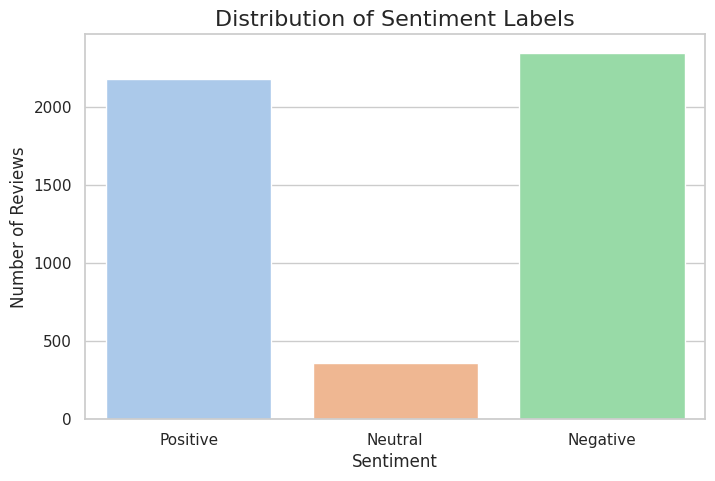

In [11]:
# Visulaize Sentiment Distribution
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# Countplot for sentiment labels
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sentiment_Label', palette='pastel', order=['Positive', 'Neutral', 'Negative'])

plt.title('Distribution of Sentiment Labels', fontsize=16)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()


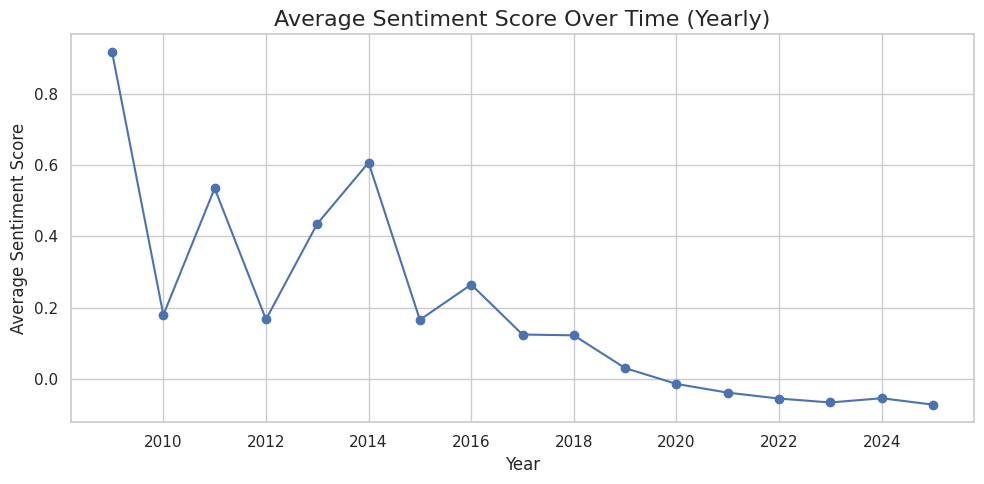

In [12]:
# Analyze sentiment trends over time
# Create 'Year' column
df['Year'] = df['Date'].dt.year

# Group by year
yearly_sentiment = df.groupby('Year')['Sentiment_Score'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(yearly_sentiment['Year'], yearly_sentiment['Sentiment_Score'], marker='o', linestyle='-')
plt.title('Average Sentiment Score Over Time (Yearly)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Average Sentiment Score')
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-13-7935e0836f00>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_region_sentiment, x='Sentiment_Score', y='Region', palette='coolwarm')


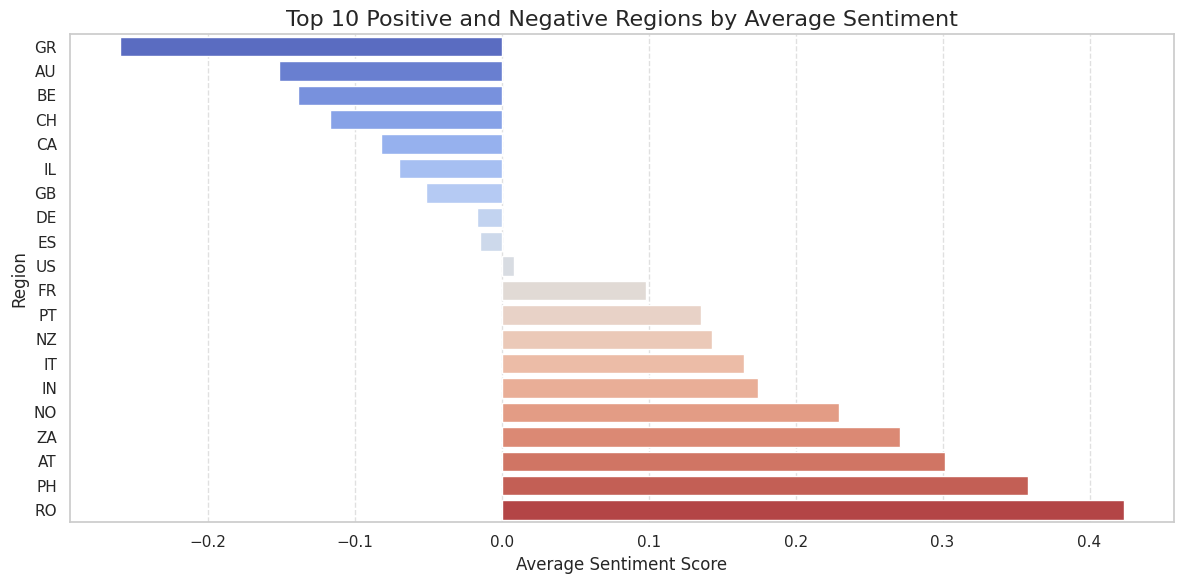

In [13]:
# Regional sentiment analysis
# Count number of reviews per region
region_counts = df['Region'].value_counts()

# Keep only regions with at least 10 reviews
valid_regions = region_counts[region_counts >= 10].index
df_valid = df[df['Region'].isin(valid_regions)]

# Group by Region again and calculate average sentiment
region_sentiment_clean = df_valid.groupby('Region')['Sentiment_Score'].mean().reset_index()

# Sort regions
region_sentiment_clean = region_sentiment_clean.sort_values(by='Sentiment_Score')

# Pick Top 10 negative and Top 10 positive regions
top_negative = region_sentiment_clean.head(10)
top_positive = region_sentiment_clean.tail(10)

# Concatenate
final_region_sentiment = pd.concat([top_negative, top_positive])

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=final_region_sentiment, x='Sentiment_Score', y='Region', palette='coolwarm')
plt.title('Top 10 Positive and Negative Regions by Average Sentiment', fontsize=16)
plt.xlabel('Average Sentiment Score')
plt.ylabel('Region')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [14]:
# Topic Modeling with LDA
!pip install scikit-learn --quiet

from sklearn.feature_extraction.text import CountVectorizer

# Use only non-null cleaned reviews
documents = df['Cleaned_Review'].dropna()

# Convert text into a bag-of-words matrix
vectorizer = CountVectorizer(max_df=0.95, min_df=5, stop_words='english')
dtm = vectorizer.fit_transform(documents)

from sklearn.decomposition import LatentDirichletAllocation



# Fit the LDA model
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)






LatentDirichletAllocation(n_components=5, random_state=42)

In [15]:
# Display Top Words per Topic
# Get feature (word) names
words = vectorizer.get_feature_names_out()

# Print top 10 words for each topic
for topic_idx, topic in enumerate(lda.components_):
    print(f"\nTopic #{topic_idx + 1}:")
    print(", ".join([words[i] for i in topic.argsort()[-10:][::-1]]))



Topic #1:
nike, return, customer, service, refund, item, received, sent, company, returned

Topic #2:
nike, service, refund, trainer, customer, told, ordered, pair, week, day

Topic #3:
nike, shoe, pair, product, buy, quality, bought, year, like, company

Topic #4:
card, nike, gift, time, website, order, buy, app, tried, dont

Topic #5:
order, customer, service, nike, day, time, shoe, delivery, ordered, told


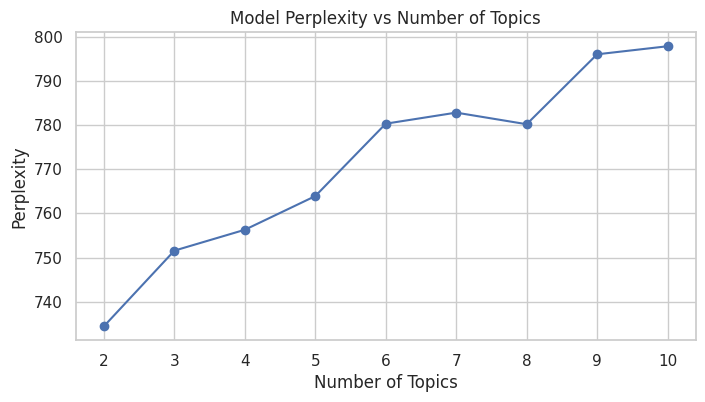

In [16]:
# Determine number of topic using perplexity
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Re-vectorize text if needed
vectorizer = CountVectorizer(max_df=0.95, min_df=5, stop_words='english')
dtm = vectorizer.fit_transform(df['Cleaned_Review'].dropna())

# Try models from 2 to 10 topics
scores = []
for k in range(2, 11):
    lda = LatentDirichletAllocation(n_components=k, random_state=42)
    lda.fit(dtm)
    scores.append(lda.perplexity(dtm))  # Lower = better

# Plot perplexity vs number of topics
plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), scores, marker='o')
plt.title('Model Perplexity vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Perplexity')
plt.grid(True)
plt.show()


In [17]:
# Retrains the final LDA with 5 topics
# Refit LDA with 5 topics (final model)
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)
# Get topic probabilities for each review
topic_results = lda.transform(dtm)

# Assign the dominant topic index
df['Dominant_Topic'] = topic_results.argmax(axis=1) + 1  # +1 to make topics 1-indexed
df[['Review', 'Cleaned_Review', 'Sentiment_Label', 'Dominant_Topic']].head(25)


,Review,Cleaned_Review,Sentiment_Label,Dominant_Topic
0,Terrible customer service I was told that I wa...,terrible customer service told crazy problem w...,Negative,5
1,If i could rate them zero I would. I will neve...,could rate zero would never buy another nike p...,Positive,1
2,good job have a good day,good job good day,Positive,5
3,Popped into my local East Kilbride Nike store ...,popped local east kilbride nike store lookgot ...,Positive,3
4,"I ordered a pair of Nike shoes on March 25, an...",ordered pair nike shoe march march received me...,Positive,5
5,Great comfort on soccer cleats with great pack...,great comfort soccer cleat great package deliv...,Positive,5
6,"Ordered a size smaller and Today, a Sunday, I ...",ordered size smaller today sunday started chat...,Positive,5
7,Very bad overall layout of the webpage. Not al...,bad overall layout webpage item displayed mode...,Negative,3
8,it is very good company i ever seen,good company ever seen,Positive,3
9,You know this brand has to be one of the most ...,know brand one populars sport wear reason boug...,Positive,3


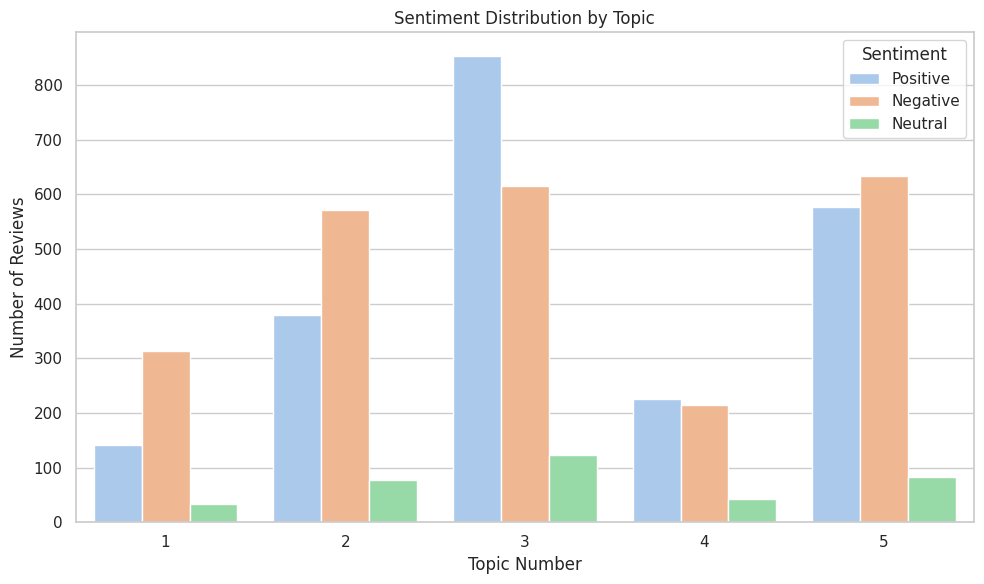

In [18]:
# Visualize sentiment distribution by topic
import seaborn as sns
import matplotlib.pyplot as plt

# Plot count of sentiment labels per topic
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Dominant_Topic', hue='Sentiment_Label', palette='pastel')
plt.title('Sentiment Distribution by Topic')
plt.xlabel('Topic Number')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()



Topic #1:
nike, return, customer, service, refund, item, received, sent, company, returned

Topic #2:
nike, service, refund, trainer, customer, told, ordered, pair, week, day

Topic #3:
nike, shoe, pair, product, buy, quality, bought, year, like, company

Topic #4:
card, nike, gift, time, website, order, buy, app, tried, dont

Topic #5:
order, customer, service, nike, day, time, shoe, delivery, ordered, told


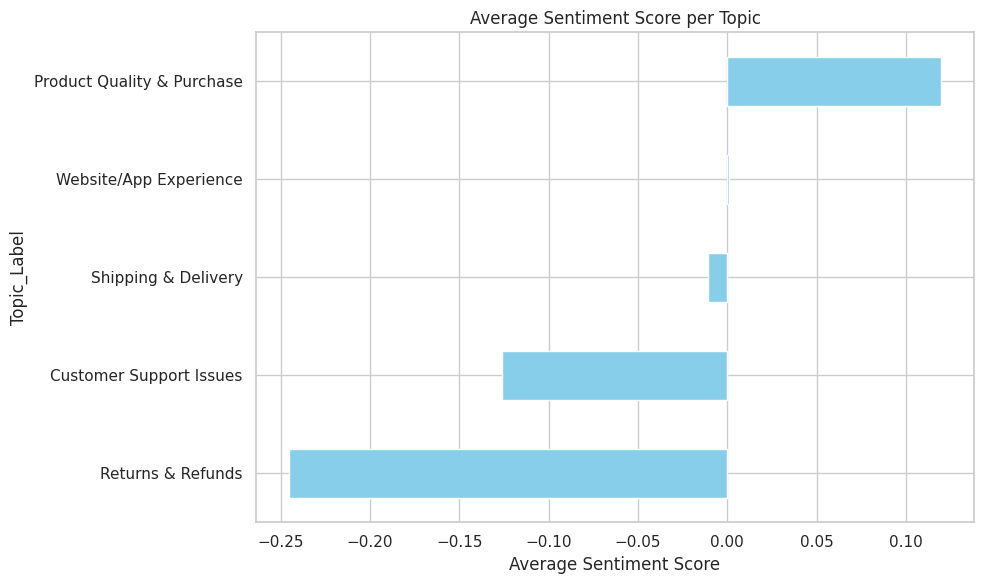

In [19]:
# Labels each topic and analyze avg sentiment score by topic
for topic_idx, topic in enumerate(lda.components_):
    print(f"\nTopic #{topic_idx + 1}:")
    print(", ".join([words[i] for i in topic.argsort()[-10:][::-1]]))

topic_map = {
    1: "Returns & Refunds",
    2: "Customer Support Issues",
    3: "Product Quality & Purchase",
    4: "Website/App Experience",
    5: "Shipping & Delivery"
}

df['Topic_Label'] = df['Dominant_Topic'].map(topic_map)
# Group by topic and calculate mean sentiment score
avg_sentiment = df.groupby('Topic_Label')['Sentiment_Score'].mean().sort_values()

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
avg_sentiment.plot(kind='barh', color='skyblue')
plt.xlabel("Average Sentiment Score")
plt.title("Average Sentiment Score per Topic")
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
# Export cleaned dataset with topics and sentiment
df[['Review', 'Cleaned_Review', 'Sentiment_Score', 'Sentiment_Label', 'Topic_Label']].to_csv("Nike_Sentiment_Topics.csv", index=False)

# Group by Topic_Label and Sentiment_Label, count occurrences
sentiment_summary = df.groupby(['Topic_Label', 'Sentiment_Label']).size().unstack(fill_value=0)

# Reorder columns (optional but tidy)
sentiment_summary = sentiment_summary[['Positive', 'Negative', 'Neutral']]

# Display the table
print(" Sentiment Summary Table by Topic")
display(sentiment_summary)


 Sentiment Summary Table by Topic


Sentiment_Label,Positive,Negative,Neutral
Topic_Label,,,
Customer Support Issues,380,572,78
Product Quality & Purchase,854,616,124
Returns & Refunds,142,313,33
Shipping & Delivery,577,633,82
Website/App Experience,226,214,43


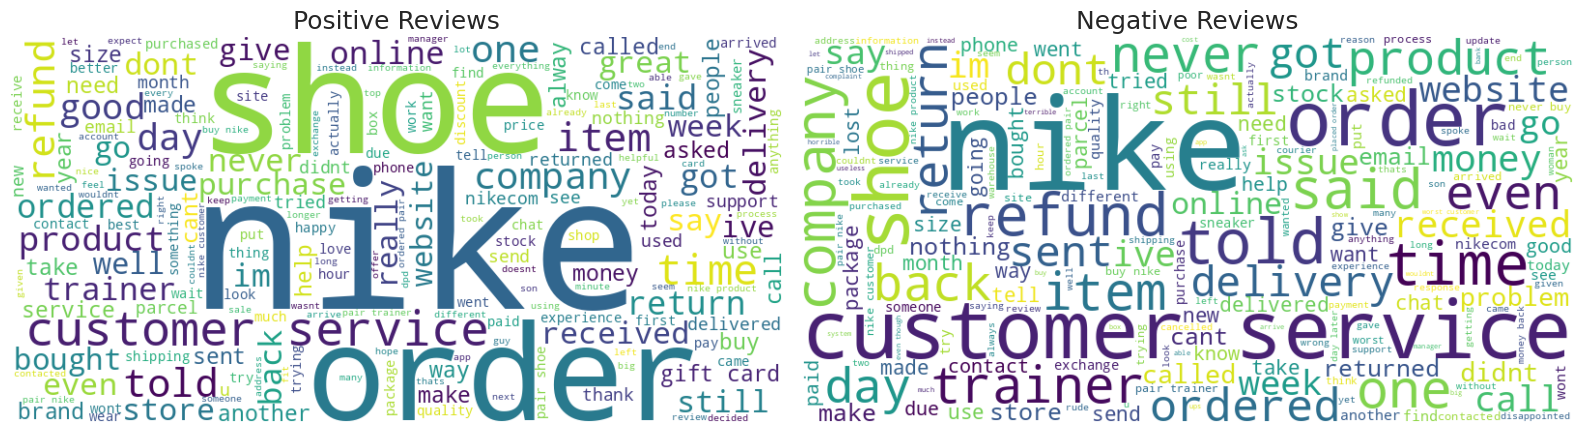

In [21]:
# Generate word cloud for positive and negative reviews
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter positive reviews
positive_text = " ".join(df[df['Sentiment_Label'] == 'Positive']['Cleaned_Review'])

# Filter negative reviews
negative_text = " ".join(df[df['Sentiment_Label'] == 'Negative']['Cleaned_Review'])

# Generate and plot word clouds
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Positive
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
ax[0].imshow(wordcloud_pos, interpolation='bilinear')
ax[0].set_title("Positive Reviews", fontsize=18)
ax[0].axis('off')

# Negative
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_text)
ax[1].imshow(wordcloud_neg, interpolation='bilinear')
ax[1].set_title("Negative Reviews", fontsize=18)
ax[1].axis('off')

plt.tight_layout()
plt.show()


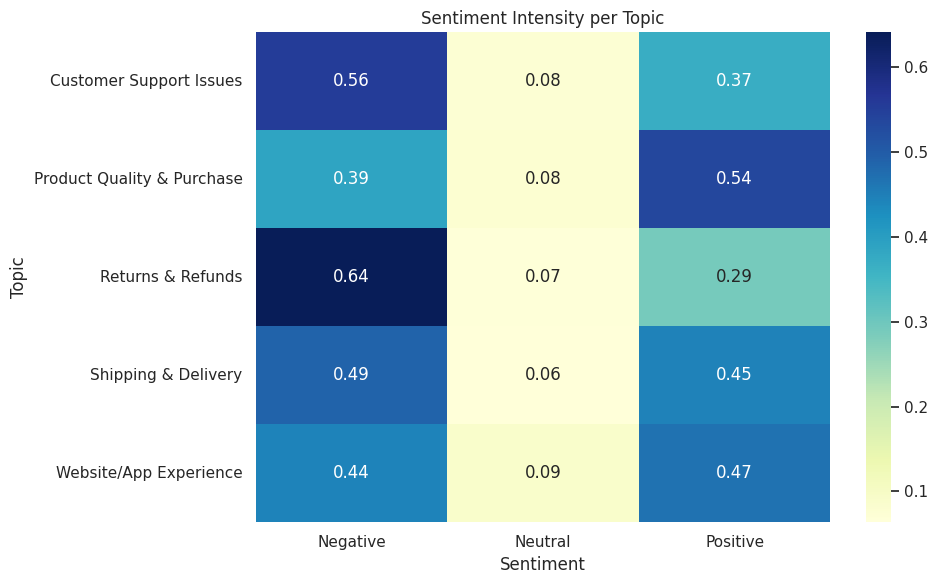

In [22]:
# Visulaize Sentiment Intensity per topic with Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Create a count matrix (topics x sentiment)
heatmap_data = df.groupby(['Topic_Label', 'Sentiment_Label']).size().unstack(fill_value=0)

# Optional: Normalize row-wise to show proportions instead of raw counts
heatmap_normalized = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_normalized, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title('Sentiment Intensity per Topic')
plt.xlabel('Sentiment')
plt.ylabel('Topic')
plt.tight_layout()
plt.show()
